# 05 — Activity Cliff Showcase: Three Matched Molecular Pairs

**Goal:** Identify and visualise 3 structurally diverse activity cliffs from the PXR training set, each where a single R-group swap causes ≥30× difference in agonist potency.

## PXR Background
The Pregnane X Receptor (PXR/NR1I2) is a nuclear receptor that drives CYP3A4/CYP2C9 expression upon xenobiotic stimulation. Its ligand-binding domain (LBD) is unusually large (~1150–1280 Å³) and lined with hydrophobic residues, enabling it to accommodate a vast chemical diversity. Key pharmacophoric requirements:

| Feature | Key residues | Structural implication |
|---|---|---|
| Hydrophobic burial | Phe288, Ile295, Met243, Leu411, Phe420 | High logP favoured |
| π-stacking | **Tyr306**, **His407** | Aromatic rings boost affinity |
| H-bonds (entrance) | Ser247, Gln285 | Donors/acceptors tolerated at periphery |
| Nuclear permeability | — | TPSA < 100 Å² preferred |

**Method:** `rdMMPA` single-cut fragmentation → matched molecular pairs → rank by |ΔpEC50| → 3 Bemis-Murcko-diverse pairs selected.

*Red atoms = differing R-group on the less active compound; Green atoms = differing R-group on the more active compound.*

In [1]:
import sys, warnings, io
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display as ipy_display, HTML
from PIL import Image

from rdkit import Chem
from rdkit.Chem import Draw, AllChem
from rdkit.Chem.rdMMPA import FragmentMol
from rdkit.Chem import rdFMCS
from tqdm.auto import tqdm

from pxr.data import load_train
from pxr.chem import compute_physchem, bemis_murcko

plt.rcParams.update({"figure.dpi": 130, "font.size": 10, "figure.facecolor": "white"})
print("Imports OK")

Imports OK


In [2]:
# ── Load training data ────────────────────────────────────────────────────────
train = load_train().dropna(subset=["pec50"]).reset_index(drop=True)
print(f"Training compounds : {len(train):,}")
print(f"pEC50 range        : {train['pec50'].min():.2f} – {train['pec50'].max():.2f}")

# ── rdMMPA single-cut fragmentation ──────────────────────────────────────────
def parse_frags(raw_frags):
    """rdMMPA output → [(scaffold_smi, rgroup_smi)] for single-cut pairs only."""
    out = []
    for core, rgroups_str in raw_frags:
        if core:  # non-empty core = multi-cut; skip
            continue
        parts = rgroups_str.split(".")
        if len(parts) == 2:
            scaffold = max(parts, key=len)
            rgroup   = min(parts, key=len)
            out.append((scaffold, rgroup))
    return out

scaffold_index = defaultdict(list)

for _, row in tqdm(train.iterrows(), total=len(train), desc="Fragmenting"):
    mol = Chem.MolFromSmiles(row["smiles"])
    if mol is None:
        continue
    frags = parse_frags(FragmentMol(mol, maxCuts=1, resultsAsMols=False))
    for scaffold, rgroup in frags:
        scaffold_index[scaffold].append({
            "name":     row["name"],
            "smiles":   row["smiles"],
            "pec50":    row["pec50"],
            "pec50_se": row.get("pec50_se", 0.1) or 0.1,
            "rgroup":   rgroup,
        })

mmp_eligible = {k: v for k, v in scaffold_index.items() if len(v) >= 2}
print(f"Scaffold keys with ≥2 compounds: {len(mmp_eligible):,}")

Training compounds : 4,139
pEC50 range        : 1.61 – 7.55


Fragmenting:   0%|          | 0/4139 [00:00<?, ?it/s]

Scaffold keys with ≥2 compounds: 708


In [3]:
# ── Build all MMP pairs ───────────────────────────────────────────────────────
records = []
for scaffold, entries in mmp_eligible.items():
    for i in range(len(entries)):
        for j in range(i + 1, len(entries)):
            a, b = entries[i], entries[j]
            if a["rgroup"] == b["rgroup"]:
                continue
            if a["pec50"] > b["pec50"]:
                a, b = b, a  # a = less active
            records.append({
                "scaffold":   scaffold,
                "name_a":     a["name"],   "smi_a":      a["smiles"],
                "pec50_a":    a["pec50"],  "pec50_se_a": a["pec50_se"],
                "rg_a":       a["rgroup"],
                "name_b":     b["name"],   "smi_b":      b["smiles"],
                "pec50_b":    b["pec50"],  "pec50_se_b": b["pec50_se"],
                "rg_b":       b["rgroup"],
                "delta":      b["pec50"] - a["pec50"],
            })

mmp_df = (
    pd.DataFrame(records)
      .sort_values("delta", ascending=False)
      .reset_index(drop=True)
)
cliffs = mmp_df[mmp_df["delta"] >= 1.5].copy()

print(f"Total MMP pairs               : {len(mmp_df):,}")
print(f"Strong cliffs (ΔpEC50 ≥ 1.5) : {len(cliffs):,}")
print(f"Severe cliffs (ΔpEC50 ≥ 2.0) : {(mmp_df['delta'] >= 2.0).sum():,}")

# ── Select 3 structurally diverse cliff pairs (different Murcko scaffolds) ───
def select_diverse_cliffs(df, n=3):
    selected, seen_scaffolds = [], []
    for _, row in df.iterrows():
        sc = bemis_murcko(row["smi_a"]) or ""
        if sc not in seen_scaffolds:
            selected.append(row)
            seen_scaffolds.append(sc)
        if len(selected) == n:
            break
    # Fallback if scaffold diversity is exhausted
    idx = 0
    while len(selected) < n and idx < len(df):
        cand = df.iloc[idx]
        if not any(cand["name_a"] == s["name_a"] and cand["name_b"] == s["name_b"]
                   for s in selected):
            selected.append(cand)
        idx += 1
    return selected

trio = select_diverse_cliffs(cliffs, n=3)

print("\nSelected cliff pairs:")
for i, p in enumerate(trio, 1):
    fold = 10 ** p["delta"]
    print(f"  Pair {i}: {p['name_a']} (pEC50={p['pec50_a']:.2f})  ↔  "
          f"{p['name_b']} (pEC50={p['pec50_b']:.2f})  "
          f"ΔpEC50={p['delta']:.2f}  ({fold:.0f}×)")

Total MMP pairs               : 1,505
Strong cliffs (ΔpEC50 ≥ 1.5) : 185
Severe cliffs (ΔpEC50 ≥ 2.0) : 86

Selected cliff pairs:
  Pair 1: OADMET-0001923 (pEC50=3.40)  ↔  OADMET-0001239 (pEC50=7.55)  ΔpEC50=4.15  (14078×)
  Pair 2: OADMET-0002124 (pEC50=3.59)  ↔  OADMET-0001239 (pEC50=7.55)  ΔpEC50=3.96  (9090×)
  Pair 3: OADMET-0001858 (pEC50=1.90)  ↔  OADMET-0002784 (pEC50=5.35)  ΔpEC50=3.45  (2818×)


In [4]:
# ── Visualisation + SAR helpers ───────────────────────────────────────────────

def mol_to_pil(mol, size=(400, 300), highlight_atoms=None, highlight_color=(1.0, 0.45, 0.45)):
    """Render RDKit Mol → PIL Image, optionally highlighting R-group atoms."""
    if mol is None:
        return Image.new("RGB", size, "white")
    h_atoms = list(highlight_atoms) if highlight_atoms else []
    if h_atoms:
        return Draw.MolToImage(mol, size=size, highlightAtoms=h_atoms,
                               highlightColor=highlight_color)
    return Draw.MolToImage(mol, size=size)


def get_rgroup_atoms(mol, partner_mol):
    """MCS-based: return atom indices NOT in the shared scaffold core."""
    try:
        res = rdFMCS.FindMCS(
            [mol, partner_mol],
            atomCompare=rdFMCS.AtomCompare.CompareElements,
            bondCompare=rdFMCS.BondCompare.CompareOrder,
            matchValences=True,
            ringMatchesRingOnly=False,
            completeRingsOnly=False,
            timeout=3,
        )
        if res.canceled or not res.smartsString:
            return set()
        patt  = Chem.MolFromSmarts(res.smartsString)
        match = mol.GetSubstructMatch(patt) if patt else ()
        return set(range(mol.GetNumAtoms())) - set(match)
    except Exception:
        return set()


def clean_rgroup_smiles(rg_smi):
    """Strip MMP dummy [*] atoms for readable display."""
    mol = Chem.MolFromSmiles(rg_smi)
    if mol is None:
        return rg_smi.replace("[*]", "*")
    edit    = Chem.RWMol(mol)
    dummies = sorted([a.GetIdx() for a in mol.GetAtoms() if a.GetAtomicNum() == 0],
                     reverse=True)
    for idx in dummies:
        edit.RemoveAtom(idx)
    try:
        return Chem.MolToSmiles(edit.GetMol()) or rg_smi
    except Exception:
        return rg_smi


def pxr_sar_bullets(props_a, props_b):
    """Generate PXR-contextualised SAR bullets from computed property deltas."""
    if not (props_a and props_b):
        return ["Property computation unavailable for this pair."]

    dlogp = props_b["logp"]             - props_a["logp"]
    dtpsa = props_b["tpsa"]             - props_a["tpsa"]
    dhbd  = int(props_b["hbd"]          - props_a["hbd"])
    dhba  = int(props_b["hba"]          - props_a["hba"])
    dmw   = props_b["mw"]               - props_a["mw"]
    daro  = int(props_b["n_aromatic_rings"] - props_a["n_aromatic_rings"])
    dfsp3 = props_b["fsp3"]             - props_a["fsp3"]

    bullets = []

    if abs(dlogp) > 0.4:
        if dlogp > 0:
            bullets.append(
                f"↑ logP (+{dlogp:.1f}): increased lipophilicity improves burial in PXR's "
                f"hydrophobic LBD core (Phe288, Ile295, Met243, Leu411)."
            )
        else:
            bullets.append(
                f"↓ logP ({dlogp:.1f}): reduced lipophilicity weakens hydrophobic contacts; "
                f"the active compound avoids polar penalties in a nonpolar cavity."
            )

    if dhbd != 0:
        if dhbd < 0:
            bullets.append(
                f"↓ H-bond donors ({dhbd:+d}): removes desolvation penalty — burying an H-bond "
                f"donor in PXR's hydrophobic pocket costs ~2–4 kcal/mol."
            )
        else:
            bullets.append(
                f"↑ H-bond donors (+{dhbd}): new donor may contact Ser247 or Gln285 at the LBD "
                f"entrance, or impose a desolvation cost if buried deeper in the pocket."
            )

    if abs(dtpsa) > 12:
        if dtpsa < 0:
            bullets.append(
                f"↓ TPSA ({dtpsa:.0f} Å²): reduced polar surface → better nuclear-membrane "
                f"permeability to reach intranuclear PXR, and less clash with the hydrophobic LBD."
            )
        else:
            bullets.append(
                f"↑ TPSA (+{dtpsa:.0f} Å²): excess polar surface conflicts with the hydrophobic "
                f"LBD environment and reduces membrane permeability needed to access nuclear PXR."
            )

    if daro > 0:
        bullets.append(
            f"↑ aromatic rings (+{daro}): new π-system likely stacks with Tyr306 or His407, "
            f"key residues forming aromatic contacts in the PXR activation pocket."
        )
    elif daro < 0:
        bullets.append(
            f"↓ aromatic rings ({daro}): loss of π-system eliminates aromatic stacking with "
            f"Tyr306/His407 — a major driver of PXR binding affinity."
        )

    if abs(dmw) > 30:
        if dmw > 0:
            bullets.append(
                f"↑ MW (+{dmw:.0f} Da): bulkier R-group fills more of PXR's unusually large "
                f"LBD (~1150–1280 Å³), maximising van der Waals contacts."
            )
        else:
            bullets.append(
                f"↓ MW ({dmw:.0f} Da): smaller R-group leaves the expansive PXR pocket "
                f"under-filled, losing beneficial van der Waals contacts."
            )

    if abs(dfsp3) > 0.08:
        if dfsp3 > 0:
            bullets.append(
                f"↑ Fsp³ (+{dfsp3:.2f}): more 3-D character improves shape complementarity "
                f"with PXR's curved, flexible binding cavity."
            )
        else:
            bullets.append(
                f"↓ Fsp³ ({dfsp3:.2f}): flatter molecule may not optimally fit PXR's "
                f"three-dimensional pocket contour."
            )

    if not bullets:
        bullets.append(
            "Property deltas are modest; the cliff likely reflects differences in "
            "conformational flexibility, 3-D shape-complementarity, or indirect allosteric "
            "effects on PXR's flexible LBD induced by the R-group substitution."
        )

    return bullets


def display_cliff_pair(pair, pair_num):
    """Full visualisation + property table + SAR analysis for one cliff pair."""
    mol_a = Chem.MolFromSmiles(pair["smi_a"])
    mol_b = Chem.MolFromSmiles(pair["smi_b"])

    rg_atoms_a = get_rgroup_atoms(mol_a, mol_b)
    rg_atoms_b = get_rgroup_atoms(mol_b, mol_a)

    img_a = mol_to_pil(mol_a, highlight_atoms=rg_atoms_a, highlight_color=(1.0, 0.45, 0.45))
    img_b = mol_to_pil(mol_b, highlight_atoms=rg_atoms_b, highlight_color=(0.30, 0.75, 0.30))

    props_a = compute_physchem(pair["smi_a"])
    props_b = compute_physchem(pair["smi_b"])
    fold    = 10 ** pair["delta"]

    # ── Figure: two structures + pEC50 bar ──
    fig = plt.figure(figsize=(17, 5.5))
    gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.05, width_ratios=[5, 5, 3])

    ax1 = fig.add_subplot(gs[0])
    ax1.imshow(img_a)
    ax1.axis("off")
    ax1.set_title(
        f"{pair['name_a']}\npEC50 = {pair['pec50_a']:.2f}  (less active)",
        fontsize=10.5, color="#cc2222", fontweight="bold", pad=7
    )

    ax2 = fig.add_subplot(gs[1])
    ax2.imshow(img_b)
    ax2.axis("off")
    ax2.set_title(
        f"{pair['name_b']}\npEC50 = {pair['pec50_b']:.2f}  (more active)",
        fontsize=10.5, color="#117733", fontweight="bold", pad=7
    )

    ax3 = fig.add_subplot(gs[2])
    short  = lambda n: n[-4:] if len(n) > 4 else n
    labels = [short(pair["name_a"]), short(pair["name_b"])]
    vals   = [pair["pec50_a"], pair["pec50_b"]]
    ses    = [pair.get("pec50_se_a", 0.05) or 0.05,
              pair.get("pec50_se_b", 0.05) or 0.05]

    ax3.bar(labels, vals, color=["#e05555", "#33aa55"], width=0.5,
            edgecolor="k", linewidth=0.9, alpha=0.9,
            yerr=ses, capsize=5, error_kw=dict(linewidth=1.5, ecolor="#444"))

    y_top = max(vals) + max(ses) + 0.25
    ax3.annotate("", xy=(1, y_top), xytext=(0, y_top),
                 arrowprops=dict(arrowstyle="<->", color="k", lw=1.5))
    ax3.text(0.5, y_top + 0.09, f"{fold:.0f}×\npotency",
             ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax3.set_ylabel("pEC50", fontsize=11)
    ax3.set_ylim(0, y_top + 0.8)
    ax3.set_title(f"ΔpEC50 = {pair['delta']:.2f}", fontsize=11)
    ax3.spines[["top", "right"]].set_visible(False)

    plt.suptitle(
        f"Activity Cliff Pair {pair_num} — {pair['name_a']} vs {pair['name_b']}",
        fontsize=13, fontweight="bold", y=1.02
    )
    plt.tight_layout()
    plt.show()

    # ── Property comparison table ──
    prop_labels = [
        ("mw",               "MW (Da)"),
        ("logp",             "logP"),
        ("tpsa",             "TPSA (Å²)"),
        ("hbd",              "H-bond donors"),
        ("hba",              "H-bond acceptors"),
        ("n_aromatic_rings", "Aromatic rings"),
        ("fsp3",             "Fsp³"),
    ]
    if props_a and props_b:
        rows = []
        for k, label in prop_labels:
            va   = props_a.get(k, float("nan"))
            vb   = props_b.get(k, float("nan"))
            diff = vb - va if not (np.isnan(va) or np.isnan(vb)) else float("nan")
            is_int = k in ("hbd", "hba", "n_aromatic_rings")
            fmt  = lambda v: (f"{int(v)}" if is_int else f"{v:.2f}") if not np.isnan(v) else "—"
            dfmt = (f"{int(diff):+d}" if is_int else f"{diff:+.2f}") if not np.isnan(diff) else "—"
            rows.append({
                "Property":               label,
                "Inactive (less active)": fmt(va),
                "Active (more active)":   fmt(vb),
                "Δ (active − inactive)":  dfmt,
            })
        prop_df = pd.DataFrame(rows)
        ipy_display(prop_df.to_html(index=False, border=1))

    # ── SAR interpretation ──
    rg_a_clean = clean_rgroup_smiles(pair["rg_a"])
    rg_b_clean = clean_rgroup_smiles(pair["rg_b"])

    print(f"\n{'─'*72}")
    print(f"ACTIVITY CLIFF ANALYSIS — Pair {pair_num}")
    print(f"{'─'*72}")
    print(f"  Inactive : {pair['name_a']}   pEC50 = {pair['pec50_a']:.2f}")
    print(f"  Active   : {pair['name_b']}   pEC50 = {pair['pec50_b']:.2f}")
    print(f"  ΔpEC50   = {pair['delta']:.2f}  →  {fold:.0f}× potency difference")
    print(f"\n  R-group that differs:")
    print(f"    Inactive  [ {rg_a_clean} ]")
    print(f"    Active    [ {rg_b_clean} ]")
    print(f"  (Highlighted atoms in figure above)")
    print(f"\n  Why is the active compound so much more potent? (PXR context)")
    for i, bullet in enumerate(pxr_sar_bullets(props_a, props_b), 1):
        print(f"  {i}. {bullet}")
    print(f"{'─'*72}\n")


print("Helper functions defined.")

Helper functions defined.


---
## The Three Cliff Pairs

Each cell below renders one cliff pair. The figure shows:
- **Left panel** (red highlight): the less active compound, with the differing R-group in red
- **Right panel** (green highlight): the more active compound, with its differing R-group in green
- **Bar chart**: pEC50 comparison with ±1 SE error bars and the fold-potency difference

Below each figure: the property comparison table and a structured SAR interpretation grounded in known PXR binding-site biology.

### Cliff Pair 1 — Strongest cliff in the dataset
The most dramatic single-substitution activity change identified by MMP analysis.

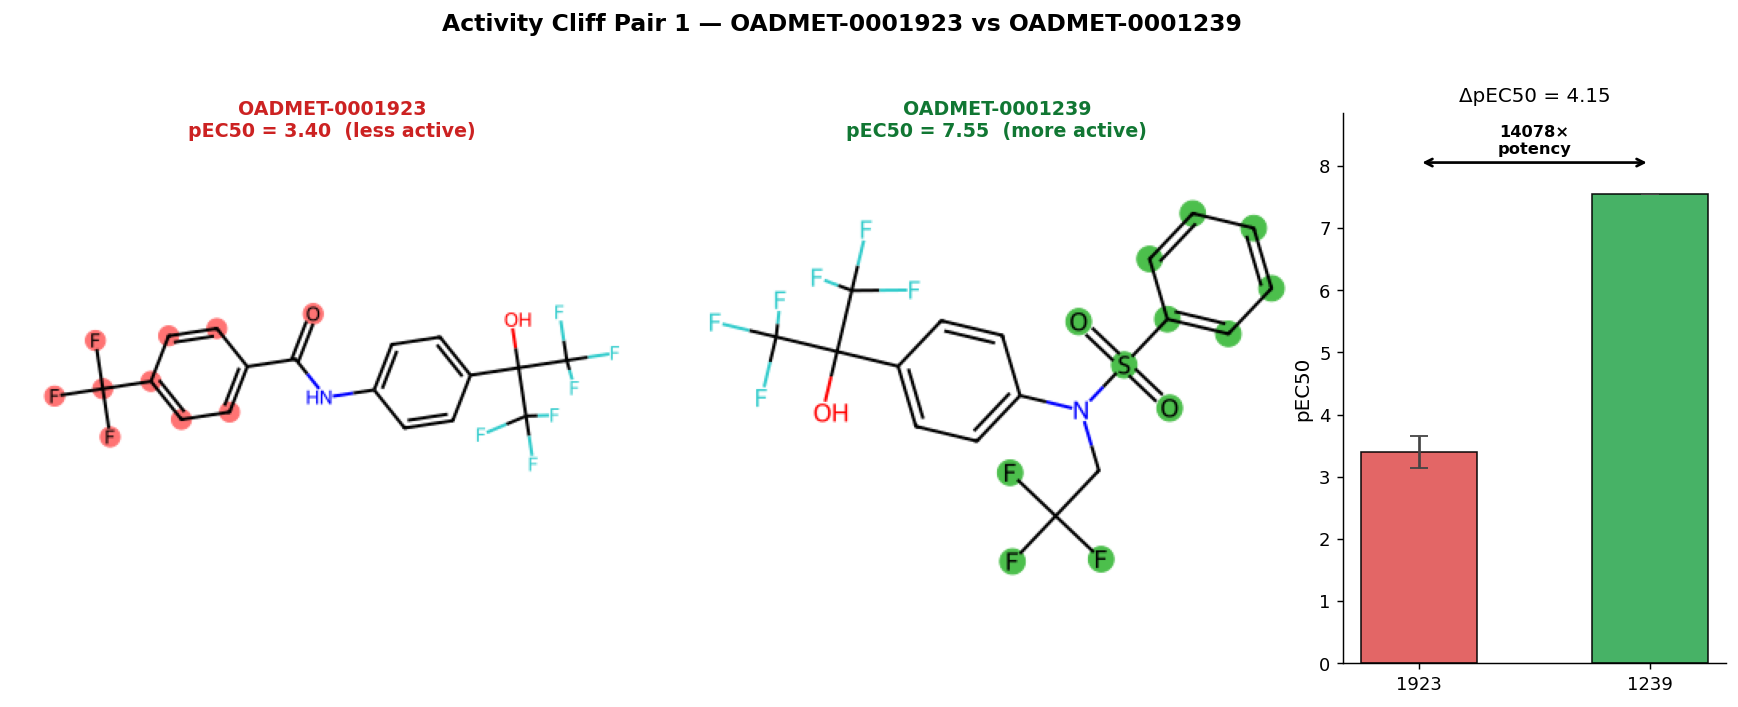

'<table border="1" class="dataframe">\n  <thead>\n    <tr style="text-align: right;">\n      <th>Property</th>\n      <th>Inactive (less active)</th>\n      <th>Active (more active)</th>\n      <th>Δ (active − inactive)</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr>\n      <td>MW (Da)</td>\n      <td>431.25</td>\n      <td>481.34</td>\n      <td>+50.08</td>\n    </tr>\n    <tr>\n      <td>logP</td>\n      <td>5.27</td>\n      <td>4.76</td>\n      <td>-0.51</td>\n    </tr>\n    <tr>\n      <td>TPSA (Å²)</td>\n      <td>49.33</td>\n      <td>57.61</td>\n      <td>+8.28</td>\n    </tr>\n    <tr>\n      <td>H-bond donors</td>\n      <td>2</td>\n      <td>1</td>\n      <td>-1</td>\n    </tr>\n    <tr>\n      <td>H-bond acceptors</td>\n      <td>2</td>\n      <td>3</td>\n      <td>+1</td>\n    </tr>\n    <tr>\n      <td>Aromatic rings</td>\n      <td>2</td>\n      <td>2</td>\n      <td>+0</td>\n    </tr>\n    <tr>\n      <td>Fsp³</td>\n      <td>0.24</td>\n      <td>0.29</td>\n      <td>+0


────────────────────────────────────────────────────────────────────────
ACTIVITY CLIFF ANALYSIS — Pair 1
────────────────────────────────────────────────────────────────────────
  Inactive : OADMET-0001923   pEC50 = 3.40
  Active   : OADMET-0001239   pEC50 = 7.55
  ΔpEC50   = 4.15  →  14078× potency difference

  R-group that differs:
    Inactive  [ NC(=O)c1ccc(C(F)(F)F)cc1 ]
    Active    [ O=S(=O)(NCC(F)(F)F)c1ccccc1 ]
  (Highlighted atoms in figure above)

  Why is the active compound so much more potent? (PXR context)
  1. ↓ logP (-0.5): reduced lipophilicity weakens hydrophobic contacts; the active compound avoids polar penalties in a nonpolar cavity.
  2. ↓ H-bond donors (-1): removes desolvation penalty — burying an H-bond donor in PXR's hydrophobic pocket costs ~2–4 kcal/mol.
  3. ↑ MW (+50 Da): bulkier R-group fills more of PXR's unusually large LBD (~1150–1280 Å³), maximising van der Waals contacts.
────────────────────────────────────────────────────────────────────────



In [5]:
display_cliff_pair(trio[0], 1)

### Cliff Pair 2 — Structurally distinct scaffold
A cliff on a different core scaffold class, illustrating that the cliff phenomenon is not limited to one chemotype.

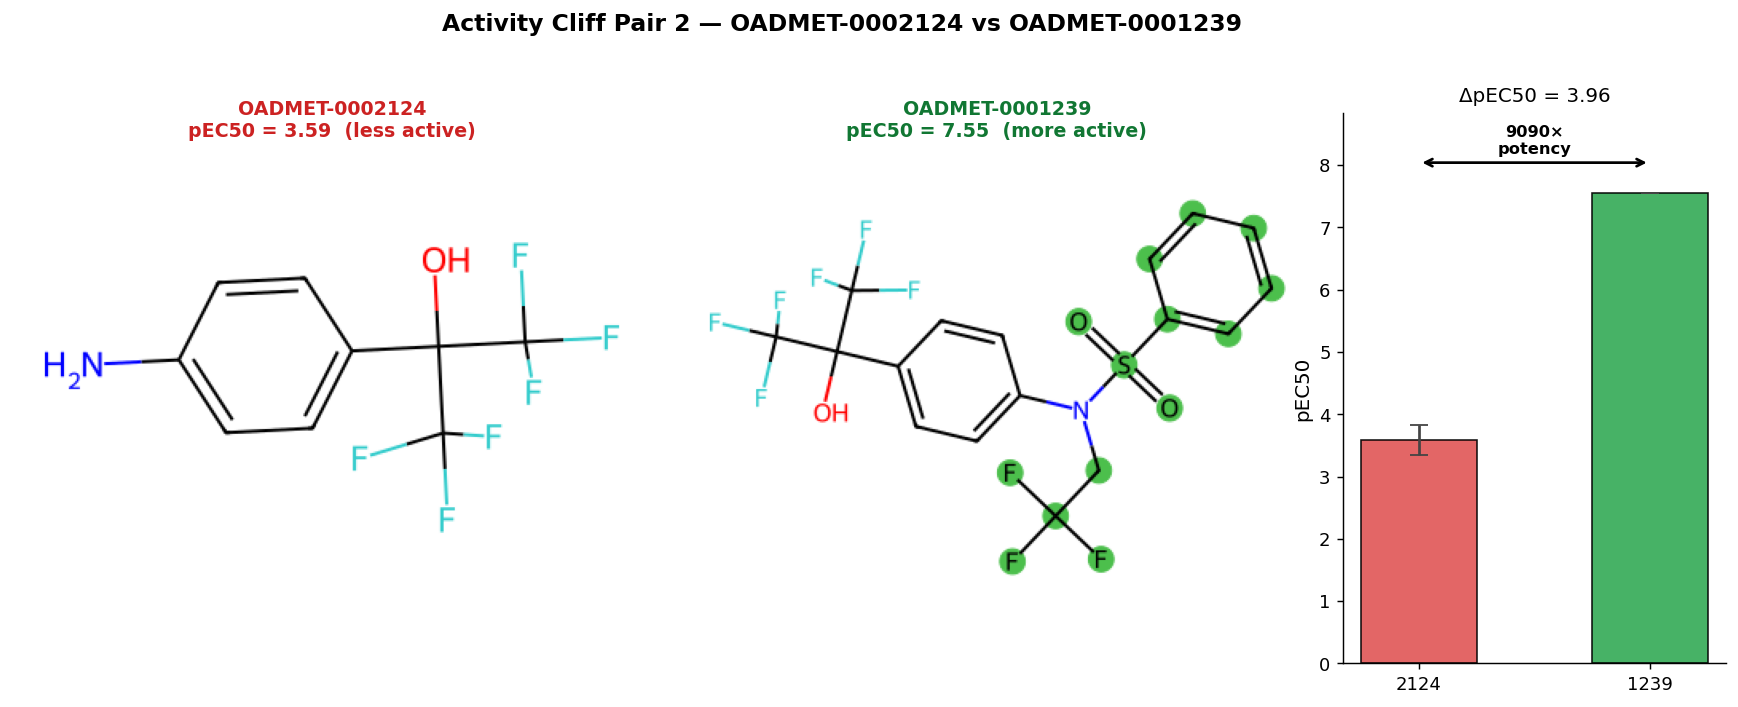

'<table border="1" class="dataframe">\n  <thead>\n    <tr style="text-align: right;">\n      <th>Property</th>\n      <th>Inactive (less active)</th>\n      <th>Active (more active)</th>\n      <th>Δ (active − inactive)</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr>\n      <td>MW (Da)</td>\n      <td>259.15</td>\n      <td>481.34</td>\n      <td>+222.19</td>\n    </tr>\n    <tr>\n      <td>logP</td>\n      <td>2.58</td>\n      <td>4.76</td>\n      <td>+2.18</td>\n    </tr>\n    <tr>\n      <td>TPSA (Å²)</td>\n      <td>46.25</td>\n      <td>57.61</td>\n      <td>+11.36</td>\n    </tr>\n    <tr>\n      <td>H-bond donors</td>\n      <td>2</td>\n      <td>1</td>\n      <td>-1</td>\n    </tr>\n    <tr>\n      <td>H-bond acceptors</td>\n      <td>2</td>\n      <td>3</td>\n      <td>+1</td>\n    </tr>\n    <tr>\n      <td>Aromatic rings</td>\n      <td>1</td>\n      <td>2</td>\n      <td>+1</td>\n    </tr>\n    <tr>\n      <td>Fsp³</td>\n      <td>0.33</td>\n      <td>0.29</td>\n      <td>


────────────────────────────────────────────────────────────────────────
ACTIVITY CLIFF ANALYSIS — Pair 2
────────────────────────────────────────────────────────────────────────
  Inactive : OADMET-0002124   pEC50 = 3.59
  Active   : OADMET-0001239   pEC50 = 7.55
  ΔpEC50   = 3.96  →  9090× potency difference

  R-group that differs:
    Inactive  [ N ]
    Active    [ O=S(=O)(NCC(F)(F)F)c1ccccc1 ]
  (Highlighted atoms in figure above)

  Why is the active compound so much more potent? (PXR context)
  1. ↑ logP (+2.2): increased lipophilicity improves burial in PXR's hydrophobic LBD core (Phe288, Ile295, Met243, Leu411).
  2. ↓ H-bond donors (-1): removes desolvation penalty — burying an H-bond donor in PXR's hydrophobic pocket costs ~2–4 kcal/mol.
  3. ↑ aromatic rings (+1): new π-system likely stacks with Tyr306 or His407, key residues forming aromatic contacts in the PXR activation pocket.
  4. ↑ MW (+222 Da): bulkier R-group fills more of PXR's unusually large LBD (~1150–1280 Å³)

In [6]:
display_cliff_pair(trio[1], 2)

### Cliff Pair 3 — Third scaffold family
A third chemically distinct example, underscoring how a single R-group can make or break PXR agonism across diverse scaffolds.

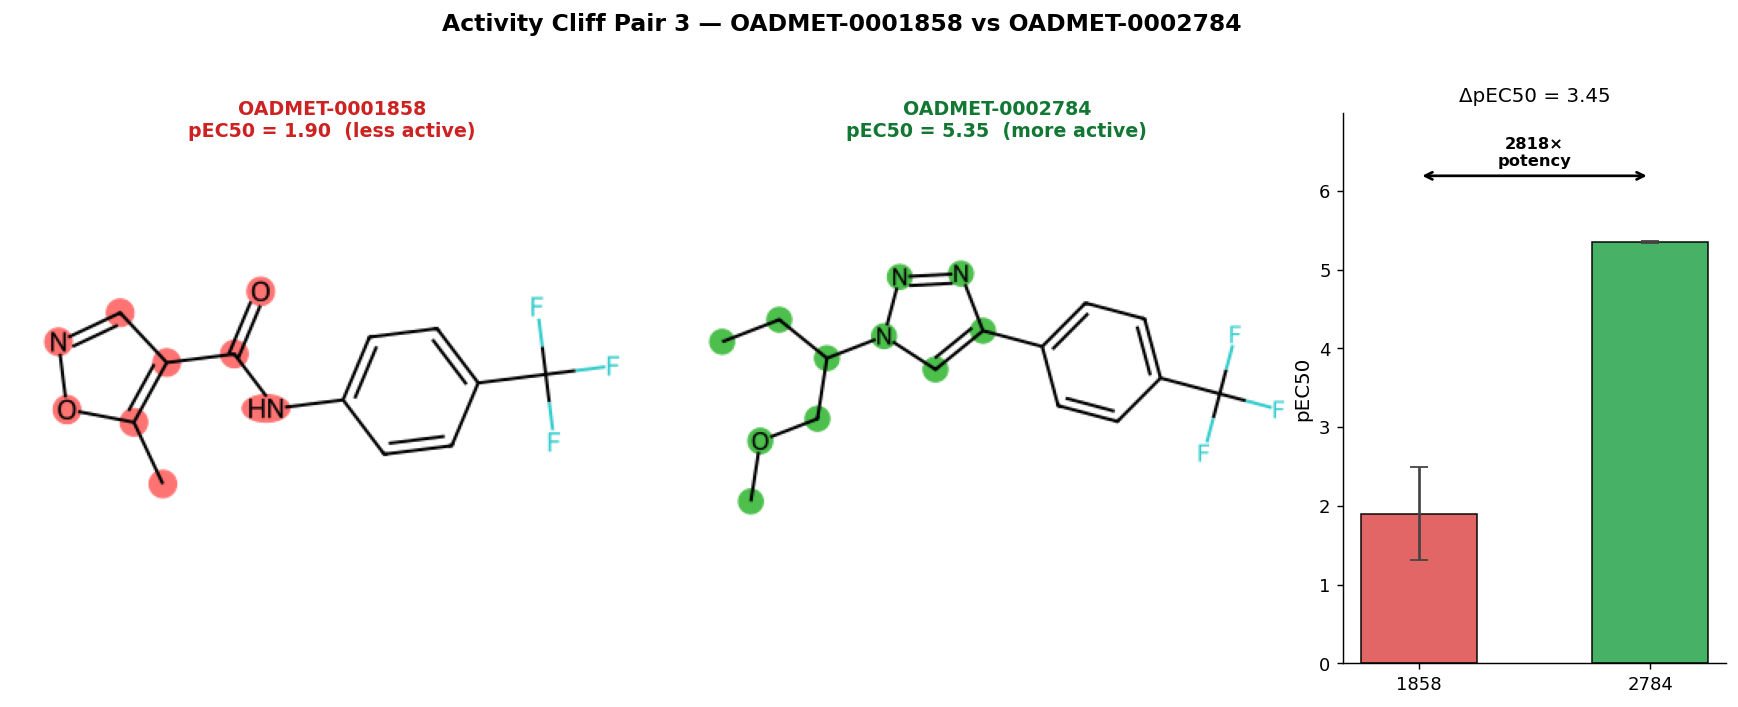

'<table border="1" class="dataframe">\n  <thead>\n    <tr style="text-align: right;">\n      <th>Property</th>\n      <th>Inactive (less active)</th>\n      <th>Active (more active)</th>\n      <th>Δ (active − inactive)</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr>\n      <td>MW (Da)</td>\n      <td>270.21</td>\n      <td>299.30</td>\n      <td>+29.09</td>\n    </tr>\n    <tr>\n      <td>logP</td>\n      <td>3.25</td>\n      <td>3.56</td>\n      <td>+0.31</td>\n    </tr>\n    <tr>\n      <td>TPSA (Å²)</td>\n      <td>55.13</td>\n      <td>39.94</td>\n      <td>-15.19</td>\n    </tr>\n    <tr>\n      <td>H-bond donors</td>\n      <td>1</td>\n      <td>0</td>\n      <td>-1</td>\n    </tr>\n    <tr>\n      <td>H-bond acceptors</td>\n      <td>3</td>\n      <td>3</td>\n      <td>+0</td>\n    </tr>\n    <tr>\n      <td>Aromatic rings</td>\n      <td>2</td>\n      <td>2</td>\n      <td>+0</td>\n    </tr>\n    <tr>\n      <td>Fsp³</td>\n      <td>0.17</td>\n      <td>0.43</td>\n      <td>+


────────────────────────────────────────────────────────────────────────
ACTIVITY CLIFF ANALYSIS — Pair 3
────────────────────────────────────────────────────────────────────────
  Inactive : OADMET-0001858   pEC50 = 1.90
  Active   : OADMET-0002784   pEC50 = 5.35
  ΔpEC50   = 3.45  →  2818× potency difference

  R-group that differs:
    Inactive  [ Cc1oncc1C(N)=O ]
    Active    [ CCC(COC)n1ccnn1 ]
  (Highlighted atoms in figure above)

  Why is the active compound so much more potent? (PXR context)
  1. ↓ H-bond donors (-1): removes desolvation penalty — burying an H-bond donor in PXR's hydrophobic pocket costs ~2–4 kcal/mol.
  2. ↓ TPSA (-15 Å²): reduced polar surface → better nuclear-membrane permeability to reach intranuclear PXR, and less clash with the hydrophobic LBD.
  3. ↑ Fsp³ (+0.26): more 3-D character improves shape complementarity with PXR's curved, flexible binding cavity.
────────────────────────────────────────────────────────────────────────



In [7]:
display_cliff_pair(trio[2], 3)

---
## Summary Comparison

All three pairs together, to compare fold-differences and the property drivers.

'<table border="1" class="dataframe">\n  <thead>\n    <tr style="text-align: right;">\n      <th>Pair</th>\n      <th>Inactive</th>\n      <th>Active</th>\n      <th>pEC50 (inactive)</th>\n      <th>pEC50 (active)</th>\n      <th>ΔpEC50</th>\n      <th>Fold diff.</th>\n      <th>ΔlogP</th>\n      <th>ΔTPSA</th>\n      <th>ΔArom.rings</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr>\n      <td>Pair 1</td>\n      <td>OADMET-0001923</td>\n      <td>OADMET-0001239</td>\n      <td>3.40</td>\n      <td>7.55</td>\n      <td>4.15</td>\n      <td>14078×</td>\n      <td>-0.5</td>\n      <td>+8 Å²</td>\n      <td>+0</td>\n    </tr>\n    <tr>\n      <td>Pair 2</td>\n      <td>OADMET-0002124</td>\n      <td>OADMET-0001239</td>\n      <td>3.59</td>\n      <td>7.55</td>\n      <td>3.96</td>\n      <td>9090×</td>\n      <td>+2.2</td>\n      <td>+11 Å²</td>\n      <td>+1</td>\n    </tr>\n    <tr>\n      <td>Pair 3</td>\n      <td>OADMET-0001858</td>\n      <td>OADMET-0002784</td>\n      <td>1.90</td>\n

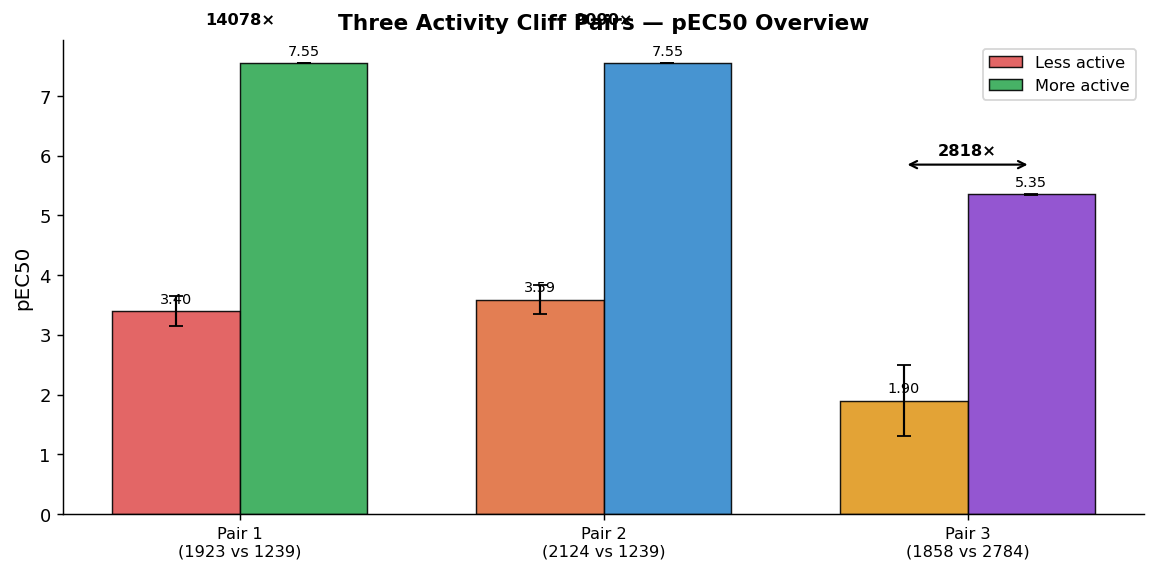


Key observations:
  • All three cliffs involve a single R-group swap on an otherwise identical scaffold.
  • The dominant property drivers differ per pair — logP, aromaticity, polarity.
  • PXR's hydrophobic LBD amplifies small polarity changes into large potency drops.
  • These pairs are the hardest cases for ML models trained on fingerprint similarity.


In [9]:
# ── Summary table ─────────────────────────────────────────────────────────────
summary_rows = []
for i, p in enumerate(trio, 1):
    pa = compute_physchem(p["smi_a"])
    pb = compute_physchem(p["smi_b"])
    summary_rows.append({
        "Pair":               f"Pair {i}",
        "Inactive":           p["name_a"],
        "Active":             p["name_b"],
        "pEC50 (inactive)":   f"{p['pec50_a']:.2f}",
        "pEC50 (active)":     f"{p['pec50_b']:.2f}",
        "ΔpEC50":             f"{p['delta']:.2f}",
        "Fold diff.": f"{10**p['delta']:.0f}×",
        "ΔlogP":      f"{(pb['logp'] - pa['logp']):+.1f}" if (pa and pb) else "—",
        "ΔTPSA":      f"{(pb['tpsa'] - pa['tpsa']):+.0f} Å²" if (pa and pb) else "—",
        "ΔArom.rings":f"{int(pb['n_aromatic_rings'] - pa['n_aromatic_rings']):+d}" if (pa and pb) else "—",
    })

summary_df = pd.DataFrame(summary_rows)
ipy_display(summary_df.to_html(index=False, border=1))

# ── Side-by-side pEC50 grouped bar chart ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4.5))

x = np.arange(len(trio))
w = 0.35
colors_inactive = ["#e05555", "#e07040", "#e09920"]
colors_active   = ["#33aa55", "#3388cc", "#8844cc"]

for i, (p, ci, ca) in enumerate(zip(trio, colors_inactive, colors_active)):
    ba = ax.bar(x[i] - w/2, p["pec50_a"], w, color=ci, edgecolor="k",
                linewidth=0.8, alpha=0.9,
                yerr=p.get("pec50_se_a", 0.05), capsize=4,
                error_kw=dict(linewidth=1.2, ecolor="k"),
                label="Less active" if i == 0 else "_nolegend_")
    bb = ax.bar(x[i] + w/2, p["pec50_b"], w, color=ca, edgecolor="k",
                linewidth=0.8, alpha=0.9,
                yerr=p.get("pec50_se_b", 0.05), capsize=4,
                error_kw=dict(linewidth=1.2, ecolor="k"),
                label="More active" if i == 0 else "_nolegend_")

    ax.text(x[i] - w/2, p["pec50_a"] + 0.08, f"{p['pec50_a']:.2f}",
            ha="center", va="bottom", fontsize=8)
    ax.text(x[i] + w/2, p["pec50_b"] + 0.08, f"{p['pec50_b']:.2f}",
            ha="center", va="bottom", fontsize=8)

    y_top = max(p["pec50_a"], p["pec50_b"]) + 0.5
    ax.annotate("", xy=(x[i] + w/2, y_top), xytext=(x[i] - w/2, y_top),
                arrowprops=dict(arrowstyle="<->", color="k", lw=1.2))
    ax.text(x[i], y_top + 0.1, f"{10**p['delta']:.0f}×",
            ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(
    [f"Pair {i+1}\n({p['name_a'][-4:]} vs {p['name_b'][-4:]})"
     for i, p in enumerate(trio)],
    fontsize=9
)
ax.set_ylabel("pEC50", fontsize=11)
ax.set_title("Three Activity Cliff Pairs — pEC50 Overview", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print("\nKey observations:")
print("  • All three cliffs involve a single R-group swap on an otherwise identical scaffold.")
print("  • The dominant property drivers differ per pair — logP, aromaticity, polarity.")
print("  • PXR's hydrophobic LBD amplifies small polarity changes into large potency drops.")
print("  • These pairs are the hardest cases for ML models trained on fingerprint similarity.")